<a href="https://colab.research.google.com/github/Omardoingthings/lab15BI/blob/main/Classification_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification - Mini-Project 2

***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: OMAR YASSER

ID: 58-11176

Tutorial: T-12

---

Name: OMAR ESSAM

ID: 61-33437

Tutorial: 12

---


## Dataset Description

The following dataset includes information about loan applicants, including factors such as income, credit score, employment status, loan details, and other indicators of financial stability, along with the final decision showing whether each loan was approved or not.

| Column | Description|
|-|-|
|ApplicationNumber|Unique identifier assigned to each loan application|
|Age|Applicant’s age in years|
|AnnualIncome|Applicant’s yearly income|
|CreditScore|A score representing the applicant’s creditworthiness|
|EmploymentStatus|Applicant’s current employment situation (Employed, Unemployed, Self-Employed)|
|EducationLevel|Highest educational qualification attained (Highschool, Bachelor, Master, Doctorate, Diploma)|
|LoanAmount|Total amount of money requested for the loan|
|LoanDuration|Duration of the loan in months|
|MaritalStatus|Applicant’s marital state (Divorced, Married, Single, Widowed)|
|NumberOfDependents|Number of individuals financially dependent on the applicant|
|HomeOwnershipStatus|Applicant’s housing status (Mortagage, Own, Rent, Other)|
|BankruptcyHistory|Indicates whether the applicant has previously declared bankruptcy (0 = No, 1 = Yes)|
|LoanPurpose|The primary reason for taking the loan (Debt Consolidation, Home Improvement, Education, Personal)|
|PreviousLoanDefaults|Indicates if the applicant has defaulted on any previous loans (0 = No, 1 = Yes)|
|MonthlyLoanPayment|Amount the applicant would need to pay monthly to repay the loan|
|MonthlyIncome|Average monthly income of the applicant|
|JobTenure|Number of years the applicant has been in their current job|
|LoanApproved|Indicates loan approval status (No = Not Approved, Yes = Approved)|

## Importing Libraries & Dataset

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#plt.style.use("seaborn")

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')
df.head()

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No


## Data Inspection

In [62]:

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

display(df.info())
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

display(df.describe(include='all').T)


Shape: (20000, 19)

Columns:
 ['ApplicationNumber', 'Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'MonthlyLoanPayment', 'MonthlyIncome', 'JobTenure', 'LoanApproved', 'MonthlyDebtToIncomeRatio']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ApplicationNumber         20000 non-null  int64  
 1   Age                       20000 non-null  int64  
 2   AnnualIncome              20000 non-null  float64
 3   CreditScore               20000 non-null  int64  
 4   EmploymentStatus          20000 non-null  object 
 5   EducationLevel            20000 non-null  object 
 6   LoanAmount                20000 non-null  float64
 7   LoanDuration   

None


Missing values:
ApplicationNumber           0
Age                         0
AnnualIncome                0
CreditScore                 0
EmploymentStatus            0
EducationLevel              0
LoanAmount                  0
LoanDuration                0
MaritalStatus               0
NumberOfDependents          0
HomeOwnershipStatus         0
BankruptcyHistory           0
LoanPurpose                 0
PreviousLoanDefaults        0
MonthlyLoanPayment          0
MonthlyIncome               0
JobTenure                   0
LoanApproved                0
MonthlyDebtToIncomeRatio    0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ApplicationNumber,20000.0,NaN,NaN,NaN,20500.5,5773.647028,10501.0,15500.75,20500.5,25500.25,30500.0
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000.0,NaN,NaN,NaN,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,20000,5,Bachelor,6054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,20000,4,Married,10041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


## Data Cleaning

In [63]:
import pandas as pd
import numpy as np
# Reload the dataframe to ensure a clean state for cleaning
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')

# Normalize column names
df.columns = df.columns.str.strip().str.replace(' ', '').str.replace('-', '').str.replace('__','_')

# Standardize expected column names
col_map = {
    'ApplicationNumber':'ApplicationNumber',
    'AppNumber':'ApplicationNumber',
    'Age':'Age',
    'AnnualIncome':'AnnualIncome',
    'Annual_Income':'AnnualIncome',
    'CreditScore':'CreditScore',
    'EmploymentStatus':'EmploymentStatus',
    'Employment_Status':'EmploymentStatus',
    'EducationLevel':'EducationLevel',
    'Education_Level':'EducationLevel',
    'LoanAmount':'LoanAmount',
    'Loan_Amount':'LoanAmount',
    'LoanDuration':'LoanDuration',
    'Loan_Duration':'LoanDuration',
    'MaritalStatus':'MaritalStatus',
    'NumberOfDependents':'NumberOfDependents',
    'HomeOwnershipStatus':'HomeOwnershipStatus',
    'BankruptcyHistory':'BankruptcyHistory',
    'LoanPurpose':'LoanPurpose',
    'PreviousLoanDefaults':'PreviousLoanDefaults',
    'MonthlyLoanPayment':'MonthlyLoanPayment',
    'Monthly_Income':'MonthlyIncome',
    'MonthlyIncome':'MonthlyIncome',
    'MonthlyLoanPayment':'MonthlyLoanPayment',
    'JobTenure':'JobTenure',
    'LoanApproved':'LoanApproved'
}

# Apply mapping for columns that exist
for src, tgt in col_map.items():
    if src in df.columns and tgt not in df.columns:
        df.rename(columns={src:tgt}, inplace=True)

# Pre-process specific string columns before numeric conversion
currency_cols = ['AnnualIncome', 'LoanAmount', 'MonthlyLoanPayment', 'MonthlyIncome']
for col in currency_cols:
    if col in df.columns:
        # Convert to string, strip whitespace, remove '$' and ',', then convert to numeric
        df[col] = df[col].astype(str).str.strip().str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce') # Convert to numeric immediately

if 'LoanDuration' in df.columns:
    # Convert to string, strip whitespace, then remove ' months' and convert to numeric
    df['LoanDuration'] = df['LoanDuration'].astype(str).str.strip().str.replace(' months', '', regex=False)
    df['LoanDuration'] = pd.to_numeric(df['LoanDuration'], errors='coerce') # Convert to numeric immediately

# Ensure other numeric candidates are numeric (coerce errors to NaN for imputation later)
numeric_candidates_other = ['Age','CreditScore','NumberOfDependents','JobTenure']
for c in numeric_candidates_other:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Normalize LoanApproved values to 0/1
if 'LoanApproved' in df.columns:
    df['LoanApproved'] = df['LoanApproved'].astype(str).str.strip().str.lower().replace({
        'yes':'Yes','y':'Yes','1':'Yes','true':'Yes','approved':'Yes',
        'no':'No','n':'No','0':'No','false':'No','not approved':'No'
    }).map({'Yes':1,'No':0})
else:
    raise KeyError("Target column 'LoanApproved' not found. Please ensure it exists in the CSV.")

# Impute missing values
# Numeric -> median, Categorical -> mode
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# dont include target in num_cols list for imputation that would change it (we already set it)
if 'LoanApproved' in num_cols:
    num_cols.remove('LoanApproved')

for c in num_cols:
    if df[c].isnull().any():
        median = df[c].median()
        df[c] = df[c].fillna(median)

for c in cat_cols:
    if df[c].isnull().any():
        mode = df[c].mode(dropna=True)
        if not mode.empty:
            df[c] = df[c].fillna(mode.iloc[0])
        else:
            df[c] = df[c].fillna('Unknown')

# safe debt-to-income ratio
if 'MonthlyLoanPayment' in df.columns and 'MonthlyIncome' in df.columns:
    df['MonthlyDebtToIncomeRatio'] = df.apply(
        lambda r: (r['MonthlyLoanPayment'] / r['MonthlyIncome']) if (pd.notnull(r['MonthlyLoanPayment']) and pd.notnull(r['MonthlyIncome']) and r['MonthlyIncome'] != 0) else np.nan,
        axis=1
    )
else:
    # create column as NaN so later code won't break
    df['MonthlyDebtToIncomeRatio'] = np.nan


print("After cleaning: shape:", df.shape)
print("Any remaining NA counts:")
print(df.isnull().sum().sort_values(ascending=False).head(20))
df.head()

After cleaning: shape: (20000, 19)
Any remaining NA counts:
ApplicationNumber           0
Age                         0
AnnualIncome                0
CreditScore                 0
EmploymentStatus            0
EducationLevel              0
LoanAmount                  0
LoanDuration                0
MaritalStatus               0
NumberOfDependents          0
HomeOwnershipStatus         0
BankruptcyHistory           0
LoanPurpose                 0
PreviousLoanDefaults        0
MonthlyLoanPayment          0
MonthlyIncome               0
JobTenure                   0
LoanApproved                0
MonthlyDebtToIncomeRatio    0
dtype: int64


,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,MonthlyDebtToIncomeRatio
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36,Single,3,Mortgage,0,Debt Consolidation,0,623.110,2249.33,3,0,0.277020
1,13176,18,22825.0,581,Self-Employed,Master,30457.0,24,Single,0,Rent,0,Home Improvement,0,1269.040,1902.08,5,0,0.667185
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,0,0.050373
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,0,0.057227
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36,Married,3,Rent,0,Home Improvement,0,778.360,2973.83,1,0,0.261737


## Exploratory Data Analysis

**Q1: On average, which type of educational level has the highest approval rate? Show their order on the graph.**

**Visualization**

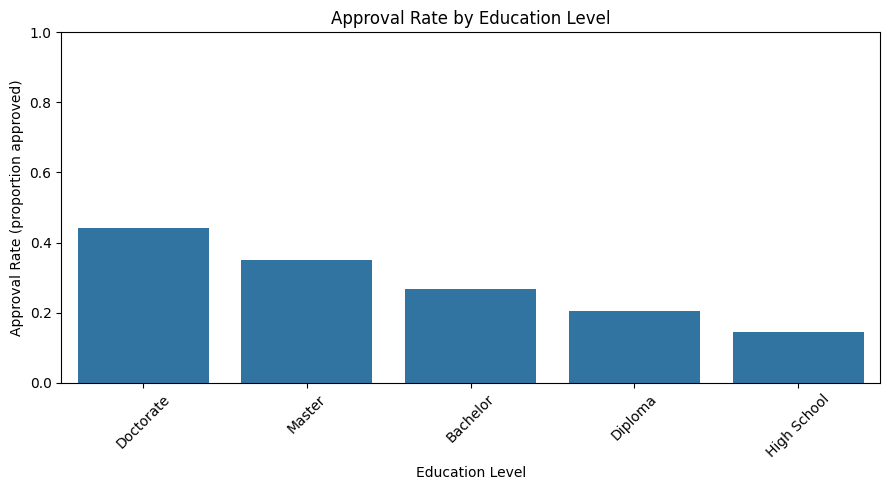

Approval rates (ordered):


,EducationLevel,ApprovalRate
0,Doctorate,0.440252
1,Master,0.350820
2,Bachelor,0.266435
3,Diploma,0.204264
4,High School,0.144381


In [53]:

if 'EducationLevel' not in df.columns:
    raise KeyError("EducationLevel column not found in dataframe.")

# compute approval rate
edu_approval = df.groupby('EducationLevel')['LoanApproved'].mean().sort_values(ascending=False)

# plot
plt.figure(figsize=(9,5))
sns.barplot(x=edu_approval.index, y=edu_approval.values)
plt.title('Approval Rate by Education Level')
plt.ylabel('Approval Rate (proportion approved)')
plt.xlabel('Education Level')
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# show numeric values
edu_approval = edu_approval.reset_index().rename(columns={'LoanApproved':'ApprovalRate'}) # Changed: renamed column to 'ApprovalRate'
print("Approval rates (ordered):")
display(edu_approval) # Changed: directly display the DataFrame

**Answer for Q1**: Doctorate holders have the highest loan approval rate, with an approval probability of 44.0%.

**Q2: How does the annual income vary among approved applicants? Interpret the values of the 3 quartiles.**

**Visualization**

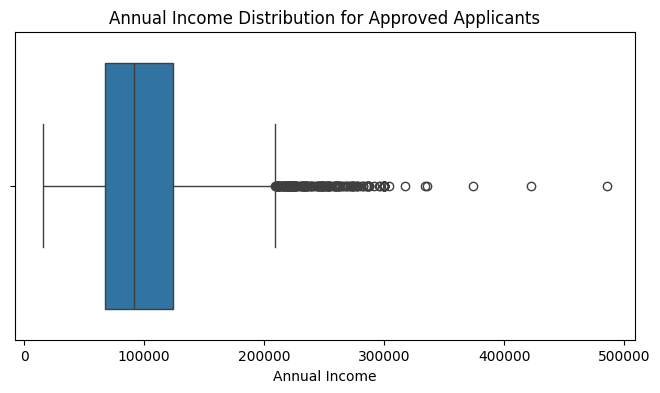

,AnnualIncome
0.25,67380.5
0.50,91269.5
0.75,123959.5


In [54]:
approved_income = df[df["LoanApproved"]==1]["AnnualIncome"]

plt.figure(figsize=(8,4))
sns.boxplot(x=approved_income)
plt.title("Annual Income Distribution for Approved Applicants")
plt.xlabel("Annual Income")
plt.show()

approved_income.quantile([0.25, 0.5, 0.75])

**Answer for Q2**: Q1 (25th percentile) =  25% of approved applicants have annual income less than or equal to 67,380.5 per year.

Q2 Median (50th percentile) = Half of approved applicants earn earn less than or equal 91,269.5 anually.

Q3 (75th percentile) = 75% of approved applicants earn up to 123,959.5 annually, while the top 25% of approved applicants earn more than that.

**Q3: How does the age of an applicant affect their credit score? (Hint: Use the line of best fit.)**

**Visualization**

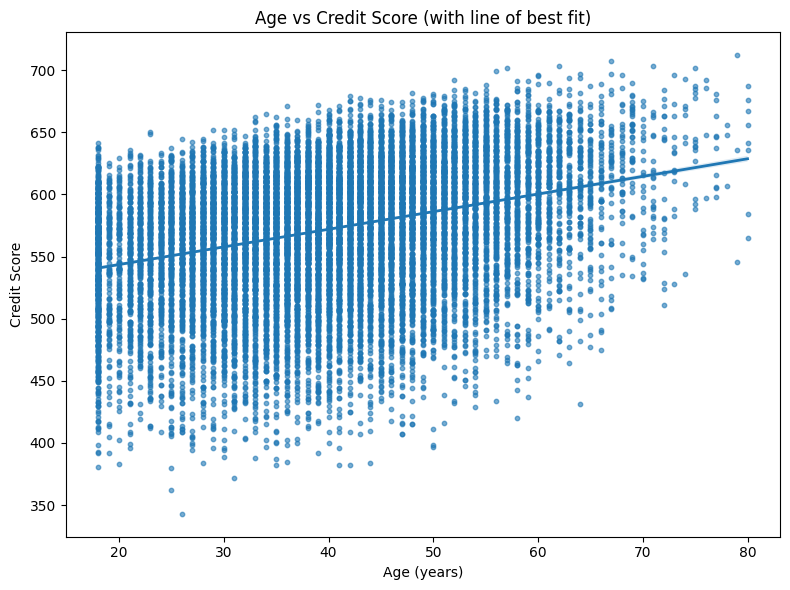

Pearson correlation between Age and CreditScore: 0.3232


In [55]:

if not {'Age','CreditScore'}.issubset(df.columns):
    raise KeyError("Columns 'Age' and/or 'CreditScore' missing.")

plt.figure(figsize=(8,6))
sns.regplot(data=df, x='Age', y='CreditScore', scatter_kws={'s':10, 'alpha':0.6}, line_kws={'lw':2})
plt.title('Age vs Credit Score (with line of best fit)')
plt.xlabel('Age (years)')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

corr = df['Age'].corr(df['CreditScore'])
print(f'Pearson correlation between Age and CreditScore: {corr:.4f}')


**Answer for Q3**: The correlation is > 0.3.Therefore, there is a moderate positive relationship, older applicants tend to have higher credit scores.

**Q4: Is the distribution of applicants' income per month normal or skewed?**

**Visualization**

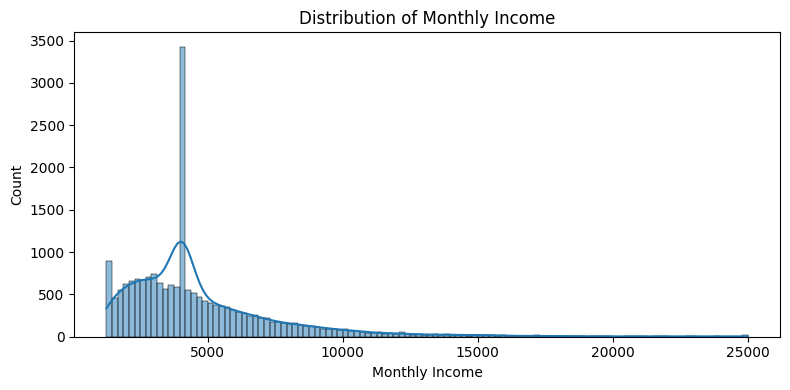

Skewness of MonthlyIncome: 2.2495
Interpretation: Distribution is positively skewed (right-skewed).


In [56]:
if 'MonthlyIncome' not in df.columns:
    raise KeyError("MonthlyIncome column not found.")

plt.figure(figsize=(8,4))
sns.histplot(df['MonthlyIncome'].dropna(), kde=True)
plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.tight_layout()
plt.show()

skewness = df['MonthlyIncome'].dropna().skew()
print(f'Skewness of MonthlyIncome: {skewness:.4f}')

if skewness > 0.5:
    print("Interpretation: Distribution is positively skewed (right-skewed).")
elif skewness < -0.5:
    print("Interpretation: Distribution is negatively skewed (left-skewed).")
else:
    print("Interpretation: Distribution is approximately symmetric / near-normal.")



**Answer for Q4**:Distribution is positively skewed (right-skewed).

*   List item
*   List item



## Data Preparation for Modelling

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Target encoding is now handled in the cleaning step
# df["LoanApproved"] = df["LoanApproved"].map({"Yes":1, "No":0})

X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modelling

In [58]:
from sklearn.tree import DecisionTreeClassifier

clf_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))
])

clf_pipe.fit(X_train, y_train)
y_pred = clf_pipe.predict(X_test)
print("Model trained.")


Model trained.


## Evaluation

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, zero_division=0))
try:
    y_probs = clf_pipe.predict_proba(X_test)[:,1]
    print("ROC AUC:", roc_auc_score(y_test, y_probs))
except Exception:
    print("Classifier does not provide probabilities for ROC AUC.")

print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.8715
Precision: 0.7407407407407407
Recall: 0.6881720430107527
F1-score: 0.7134894091415831
ROC AUC: 0.9199077090119434

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92      3070
           1       0.74      0.69      0.71       930

    accuracy                           0.87      4000
   macro avg       0.82      0.81      0.82      4000
weighted avg       0.87      0.87      0.87      4000



## Bonus (Optional)

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('preproc', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1:", f1_score(y_test, y_pred_rf, zero_division=0))


Random Forest Accuracy: 0.89025
Random Forest F1: 0.746096009253904
